# Welcome to Colab!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA   # optional, for dimensionality reduction

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("energy_data.csv")

print(df.head())
print(df.info())
print(df.describe())


          timestamp     location  energy_consumption  temperature
0  01-01-2023 00:00   Industrial          139.101364    33.820542
1  01-01-2023 01:00  Residential          247.109808    26.392602
2  01-01-2023 02:00   Industrial          233.934693    25.027439
3  01-01-2023 03:00   Industrial          243.013532    27.107712
4  01-01-2023 04:00  Residential          313.502582    27.326153
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           10000 non-null  object 
 1   location            10000 non-null  object 
 2   energy_consumption  10000 non-null  float64
 3   temperature         10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB
None
       energy_consumption   temperature
count        10000.000000  10000.000000
mean           275.404802     24.991026
std            129.29072

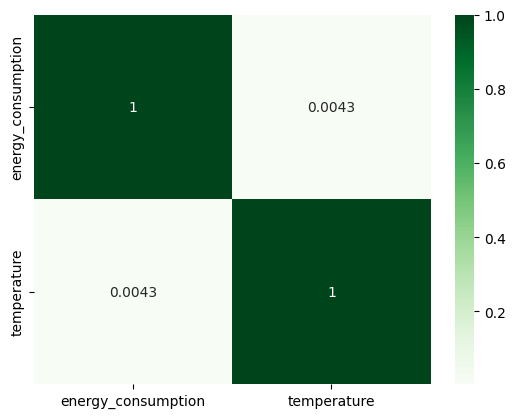

In [ ]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Greens")
plt.show()

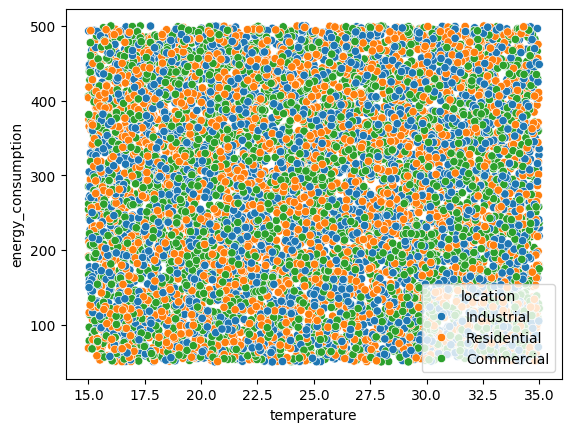

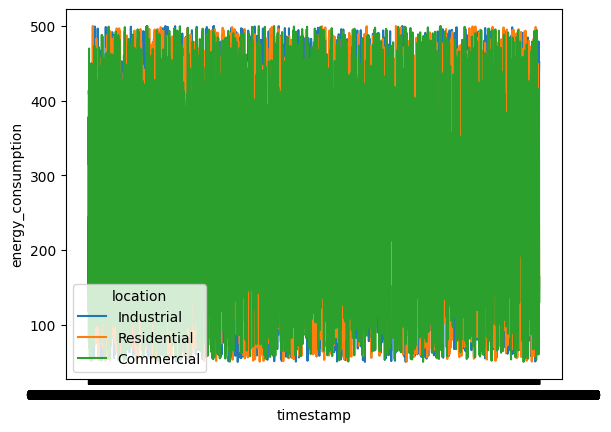

In [ ]:
sns.scatterplot(data=df, x="temperature", y="energy_consumption", hue="location")
plt.show()

sns.lineplot(data=df, x="timestamp", y="energy_consumption", hue="location")
plt.show()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month


In [ ]:
print(df.isnull().sum())
df['energy_consumption'].fillna(df['energy_consumption'].median(), inplace=True)
df['temperature'].fillna(df['temperature'].mean(), inplace=True)
df['location'].fillna("Unknown", inplace=True)


timestamp             0
location              0
energy_consumption    0
temperature           0
hour                  0
day                   0
month                 0
dtype: int64


/tmp/ipykernel_775/839126729.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['energy_consumption'].fillna(df['energy_consumption'].median(), inplace=True)
/tmp/ipykernel_775/839126729.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

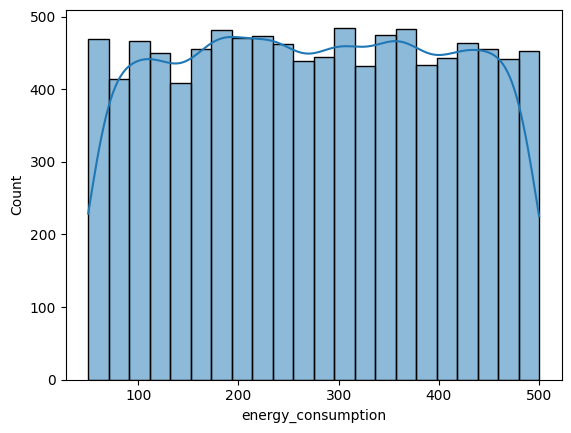

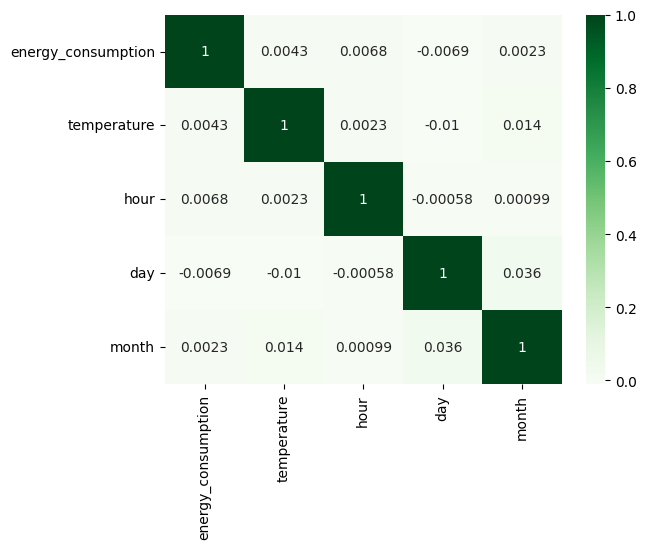

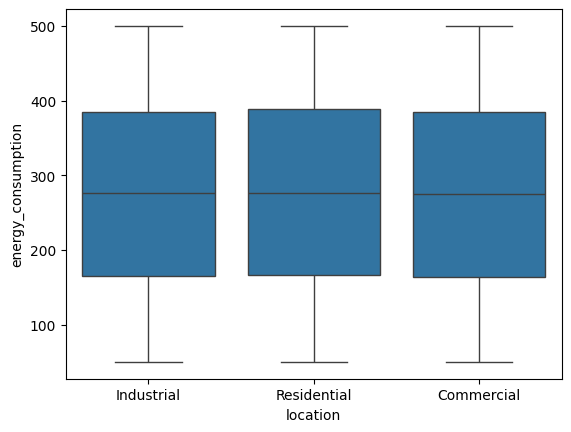

In [ ]:
# Distribution
sns.histplot(df['energy_consumption'], kde=True)
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Greens")
plt.show()

# Boxplot by location
sns.boxplot(data=df, x="location", y="energy_consumption")
plt.show()

In [ ]:
# Create the feature first
df['energy_per_temp'] = df['energy_consumption'] / df['temperature']

# Now apply scaling
from sklearn.preprocessing import StandardScaler, LabelEncoder

scaler = StandardScaler()
df[['energy_consumption','temperature','energy_per_temp']] = scaler.fit_transform(
    df[['energy_consumption','temperature','energy_per_temp']]
)

encoder = LabelEncoder()
df['location'] = encoder.fit_transform(df['location'])


In [ ]:
scaler = StandardScaler()
df[['energy_consumption','temperature','energy_per_temp']] = scaler.fit_transform(
    df[['energy_consumption','temperature','energy_per_temp']]
)

encoder = LabelEncoder()
df['location'] = encoder.fit_transform(df['location'])


In [ ]:
# Feature engineering
df['energy_per_temp'] = df['energy_consumption'] / df['temperature']

# Scaling
scaler = StandardScaler()
df[['energy_consumption','temperature','energy_per_temp']] = scaler.fit_transform(
    df[['energy_consumption','temperature','energy_per_temp']]
)

# Encoding
encoder = LabelEncoder()
df['location'] = encoder.fit_transform(df['location'])

# Preview
df.head()


,timestamp,location,energy_consumption,temperature,hour,day,month,energy_per_temp
0,2023-01-01 00:00:00,1,-1.054293,1.526844,0,1,1,-0.011309
1,2023-01-01 01:00:00,2,-0.218859,0.242368,1,1,1,-0.012420
2,2023-01-01 02:00:00,1,-0.320767,0.006297,2,1,1,-0.274196
3,2023-01-01 03:00:00,1,-0.250543,0.366028,3,1,1,-0.011277
4,2023-01-01 04:00:00,2,0.294682,0.403802,4,1,1,-0.003879
